<div style="background-color:#2F6BFF; color:white; padding:15px; border-radius:8px;">
<h1 style="text-align:center; font-size:18px;">HR ANALYTICS: FACTORS INFLUENCING EMPLOYEE JOB CHANGE</h1>
</div>

<div>
  <h3>PROJECT OBJECTIVE</h3>
  <p>

  </p>
</div>

To analyze HR analytics data using Python in order to identify the key factors that influence employees’ decisions to change jobs, based on variables such as education level, work experience, company characteristics, and training hours.

  ##                     1.DATA LOADING AND INITIAL OVERVIEW

In [1]:
import pandas as pd
import numpy as np 

In [2]:
#Load the dataset
df = pd.read_csv("aug_train.csv")

In [3]:
#Number of rows and columns
df.shape

(19158, 14)

In [4]:
#Data types of each column
df.dtypes

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

In [5]:
df.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [7]:
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [5]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target', 'experience_num',
       'training_level', 'is_high_education'],
      dtype='object')

                          Summary of Data Loading and Initial Overview:

The dataset was successfully loaded using the Pandas library and an initial exploration was performed. Basic information such as the number of rows and columns, data types of each column, and sample records were examined. Functions like head(), info(), and describe() helped in understanding the structure of the dataset, identifying numerical and categorical variables, and detecting the presence of missing values.

This initial overview provides a clear understanding of the dataset and prepares the data for further data cleaning, preprocessing, and exploratory data analysis.

##                   2.DATA PRE - PROCESSING

<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
2.1 HANDLING MISSING VALUES
</h3>

In [5]:
# Check missing values
import pandas as pd
import numpy as  np
df = pd.read_csv("aug_train.csv")
df.isnull().sum()



enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [7]:
# Categorical values with mode,
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [8]:
# Numerical values with median
df['training_hours'] = df['training_hours'].fillna(df['training_hours'].median())

In [9]:
  # Missing values in all object columns with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
# Missing values in all object columns with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
2.2 REMOVING DUPLICATES
</h3>

In [11]:
# Checking duplicate Rows
df.duplicated().sum()

np.int64(0)

There is no duplicate rows in the dataset.

<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
2.3 CORRECTING DATA TYPES
</h3>

In [25]:
# Check data type
df.dtypes

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                  int64
company_size               object
company_type               object
last_new_job                int64
training_hours              int64
target                      int64
dtype: object

In [5]:
# Convert Target to Integer
df.columns = df.columns.str.strip()
df = df.copy()
df['target'] = pd.to_numeric(df['target'], errors='coerce')
df['target'] = df['target'].astype('int64')

print(df['target'].dtype)
print(df['target'].unique())

int64
[1 0]


In [6]:
# Convert experience to Numeric
df.columns = df.columns.str.strip()
df = df.copy()
df['experience'] = df['experience'].astype(str).str.strip()

df['experience'] = df['experience'].replace({
    '<1': '0',
    '>20': '21'})

df['experience'] = df['experience'].str.extract('(\d+)')
df['experience'] = pd.to_numeric(df['experience'], errors='coerce')


df['experience'] = df['experience'].fillna(df['experience'].median())
df['experience'] = df['experience'].astype(int)


print(df['experience'].dtype)
print(df['experience'].head())

int64
0    21
1    15
2     5
3     0
4    21
Name: experience, dtype: int64


In [7]:
# Convert last_new_job to Numeric
df.columns = df.columns.str.strip()
df = df.copy()
df['last_new_job'] = df['last_new_job'].astype(str).str.strip()
df['last_new_job'] = df['last_new_job'].replace({'never': '0','>4': '5'})
df['last_new_job'] = df['last_new_job'].str.extract('(\d+)')
df['last_new_job'] = pd.to_numeric(df['last_new_job'], errors='coerce')
df['last_new_job'] = df['last_new_job'].fillna(df['last_new_job'].median())
df['last_new_job'] = df['last_new_job'].astype(int)

print(df['last_new_job'].dtype)
print(df['last_new_job'].unique())

int64
[1 5 0 4 3 2]


<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
2.4 CREATING DERIVED COLUMNS
</h3>

In [2]:
# Experience in Numbers
import pandas as pd

df = pd.read_csv("aug_train.csv")

# Convert experience to numeric
df["experience_num"] = df["experience"].replace({">20": 21, "<1": 0}).astype(float)

print(df[["experience", "experience_num"]].head())

  experience  experience_num
0        >20            21.0
1         15            15.0
2          5             5.0
3         <1             0.0
4        >20            21.0


In [3]:
# Training Intensity
# Training intensity category
df["training_level"] = df["training_hours"].apply(lambda x: "Low" if x < 30 else ("Medium" if x < 60 else "High"))

print(df[["training_hours", "training_level"]].head())

   training_hours training_level
0              36         Medium
1              47         Medium
2              83           High
3              52         Medium
4               8            Low


In [4]:
# Education Flag
# Check if highly educated
df["is_high_education"] = df["education_level"].isin(["Graduate", "Masters", "Phd"])

print(df[["education_level", "is_high_education"]].head(10))

  education_level  is_high_education
0        Graduate               True
1        Graduate               True
2        Graduate               True
3        Graduate               True
4         Masters               True
5        Graduate               True
6     High School              False
7        Graduate               True
8        Graduate               True
9        Graduate               True


<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
2.5 FILTERING OR AGGREGATING DATA
</h3>

In [6]:
# Filter employees with experience > 5
import pandas as pd

df.columns = df.columns.str.strip()

df['experience'] = pd.to_numeric(df['experience'], errors='coerce')

filtered_df = df[df['experience'] > 5][['enrollee_id', 'experience']]

print(filtered_df)

       enrollee_id  experience
1            29725        15.0
5            21651        11.0
7              402        13.0
8            27107         7.0
9              699        17.0
...            ...         ...
19149          251         9.0
19150        32313        10.0
19152        29754         7.0
19153         7386        14.0
19154        31398        14.0

[9422 rows x 2 columns]


In [7]:
# Aggregation
# Average training hours (no grouping)
import pandas as pd

df['training_hours'] = pd.to_numeric(df['training_hours'], errors='coerce')

avg_training = df['training_hours'].mean()
print(avg_training)

65.36689633573442


## DATA PRE-PROCESSING SUMMARY:

Data preprocessing involves cleaning and transforming raw data by handling missing values, removing duplicates, and converting data into appropriate formats. It also includes encoding categorical variables, applying filtering and aggregation techniques, and selecting relevant features to ensure the dataset is accurate, consistent, and ready for analysis.

##                        3.EXPLORATORY DATA ANALYSIS(EDA)

<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
3.1 UNIVARIATE ANALYSIS
</h3>

In [8]:
# Training Hours Analysis
import pandas as pd

df = pd.read_csv("aug_train.csv")


print(df["training_hours"].describe())

count    19158.000000
mean        65.366896
std         60.058462
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        336.000000
Name: training_hours, dtype: float64


<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
3.2 BIVARIATE ANALYSIS
</h3>

In [14]:
#Average Training Hours by Target

df['training_hours'] = pd.to_numeric(df['training_hours'], errors='coerce')

result = df.groupby('target')['training_hours'].mean()

print(result)

target
0.0    66.113761
1.0    63.118484
Name: training_hours, dtype: float64


<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
3.3 MULTIVARIATE ANALYSIS
</h3>

In [3]:
#Experience and Training Hours by Target
import pandas as pd

df = pd.read_csv("aug_train.csv")

#Convert to string first
df['experience'] = df['experience'].astype(str)

#Extract numbers
df['experience'] = df['experience'].str.extract('(\d+)')

#Convert to numeric
df['experience'] = pd.to_numeric(df['experience'], errors='coerce')

df['experience'] = df['experience'].fillna(df['experience'].median())
df['training_hours'] = df['training_hours'].fillna(df['training_hours'].median())

#Groupby
result = df.groupby('target')[['experience', 'training_hours']].mean()

print(result)


        experience  training_hours
target                            
0.0      10.610806       66.113761
1.0       7.969228       63.118484


<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
3.4 GROUPBY ANALYSIS
</h3>

In [18]:
#Average Training Hours and City Development Index by Company Type
df.groupby('company_type').agg({
    'training_hours': 'mean',
    'city_development_index': 'mean'})

,training_hours,city_development_index
company_type,,
Early Stage Startup,69.489221,0.793653
Funded Startup,66.997003,0.847005
NGO,67.856046,0.845931
Other,69.000000,0.852702
Public Sector,62.050262,0.861199
Pvt Ltd,65.277274,0.832877


<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
3.5 PIVOT TABLE

</h3>

In [19]:
# Average Training Hours by Company Type and Target
pd.pivot_table(
    df,
    values='training_hours',
    index='company_type',
    columns='target',
    aggfunc='mean')

target,0.0,1.0
company_type,,
Early Stage Startup,69.746204,68.654930
Funded Startup,68.001161,60.821429
NGO,67.936321,67.505155
Other,68.336957,71.103448
Public Sector,62.402685,60.800000
Pvt Ltd,65.725068,63.248451


<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
3.6 STATISTICAL SUMMARY
</h3>

In [20]:
# Statistical Summary of Training Hours and City Development Index
df[['training_hours', 'city_development_index']].describe()

,training_hours,city_development_index
count,19158.000000,19158.000000
mean,65.366896,0.828848
std,60.058462,0.123362
min,1.000000,0.448000
25%,23.000000,0.740000
50%,47.000000,0.903000
75%,88.000000,0.920000
max,336.000000,0.949000


<h3 style="text-align:center; font-size:20px; font-weight:700; margin:0; letter-spacing:0.5px; color:#2F6BFF;">
3.7 CORRELATION HEATMAP
</h3>

Matplotlib is building the font cache; this may take a moment.


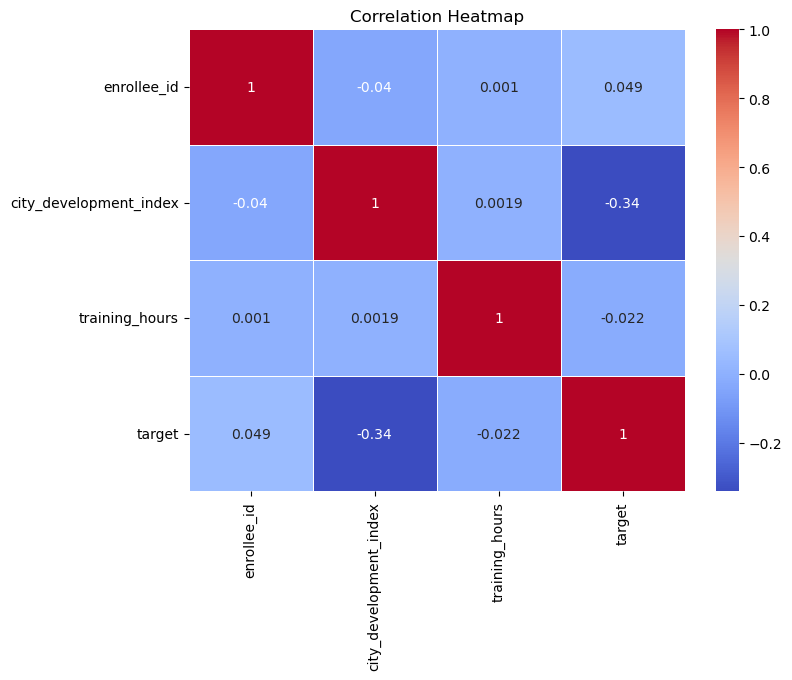

In [21]:
# CORRELATION HEATMAP
import seaborn as sns
import matplotlib.pyplot as plt


corr = df.corr(numeric_only=True)


plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

## EXPLORATORY DATA ANALYSIS SUMMARY:

The exploratory data analysis (EDA) examined the dataset’s structure, distribution, and relationships. Most variables, including the target, are fairly balanced, supporting meaningful comparisons. Key factors like experience, training hours, education, and company type show some influence on the target. Correlations are generally weak to moderate, indicating independent contributions, while a few outliers—especially in training hours—were noted. Overall, EDA revealed patterns, anomalies, and insights to guide further modeling and decisions.

##                                    4.VISUALIZATIONS

## 1.BAR CHART (TARGET DISTRIBUTION)

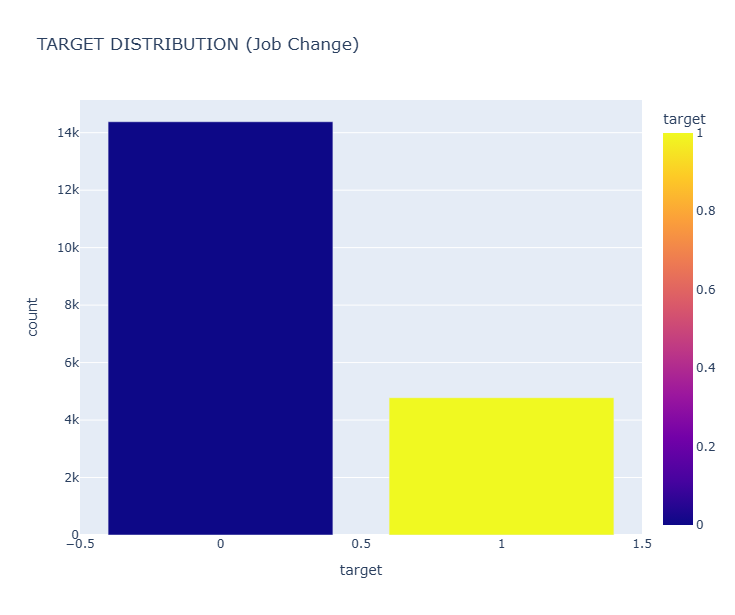

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv("aug_train.csv")


target_counts = df['target'].value_counts().reset_index()
target_counts.columns = ['target', 'count']


fig = px.bar( target_counts,x='target', y='count',color='target',
    title="TARGET DISTRIBUTION (Job Change)",
    color_discrete_sequence=['#AA00FF'])


fig.update_layout(width=1000, height=600)
fig.show()

## 2.HISTOGRAM (EDUCATION LEVEL)

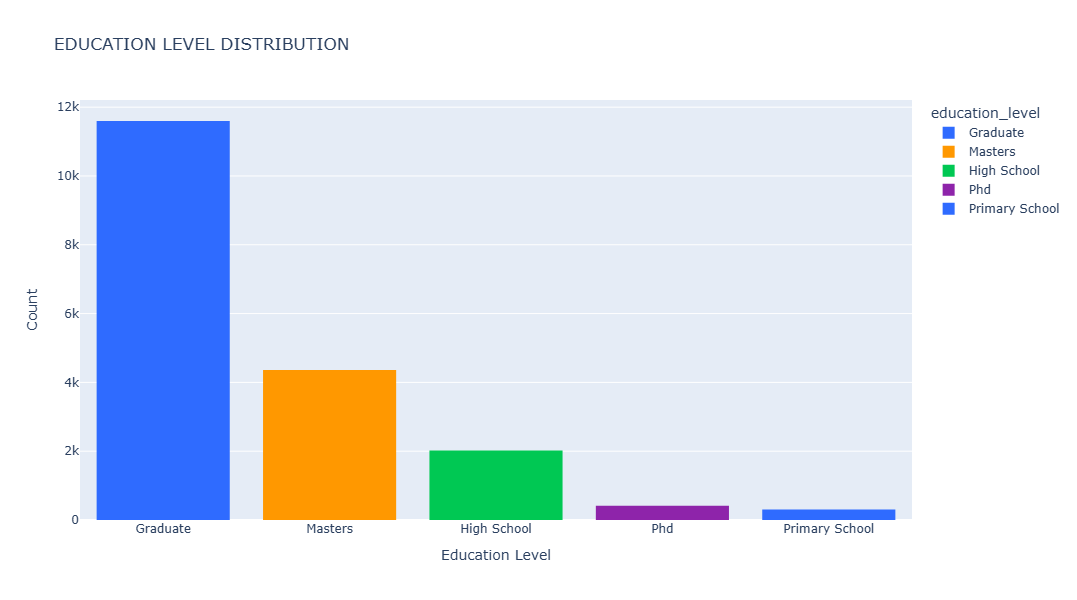

In [7]:
import plotly.express as px

fig = px.histogram(df,x='education_level',color='education_level',title="EDUCATION LEVEL DISTRIBUTION",
                   color_discrete_sequence=['#2F6BFF','#FF9800','#00C853','#FF3B3B','#8E24AA'])

fig.update_layout( width=900, height=600, xaxis_title="Education Level",yaxis_title="Count")


fig.show()

## 3.PIE CHART (EXPERIENCE DISTRIBUTION)

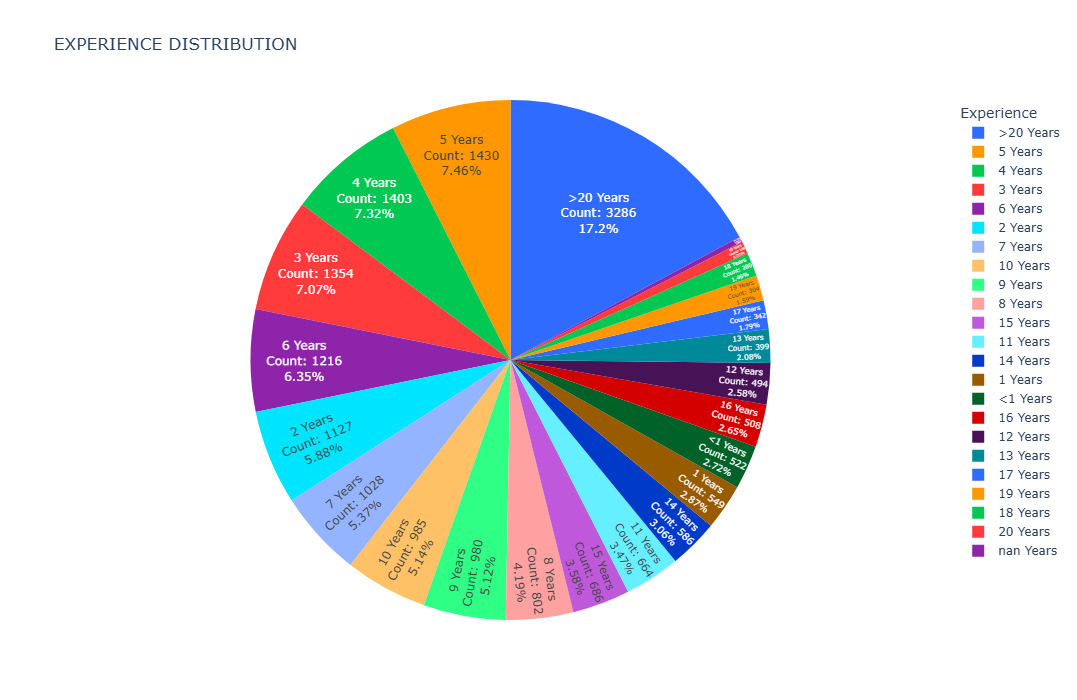

In [8]:
import plotly.express as px


df['experience_label'] = df['experience'].astype(str) + " Years"

fig = px.pie(df,names='experience_label',title="EXPERIENCE DISTRIBUTION",
             color_discrete_sequence=['#2F6BFF','#FF9800','#00C853','#FF3B3B','#8E24AA','#00E5FF'])


fig.update_traces(texttemplate='%{label}<br>Count: %{value}<br>%{percent}',textposition='inside')
fig.update_layout(legend_title="Experience",width=900, height=700)


fig.show()

## 4.VIOLIN PLOT (EXPERIENCE VS TRAINING HOURS)¶

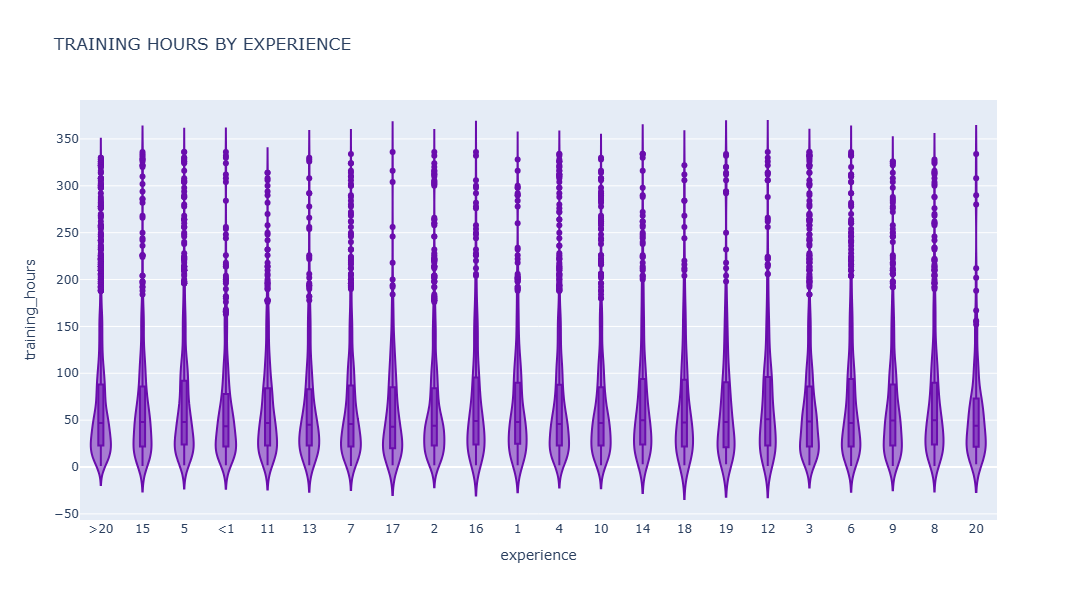

In [9]:
fig = px.violin(df,x='experience',y='training_hours',
                title="TRAINING HOURS BY EXPERIENCE",
                box=True,
                points='outliers',
                color_discrete_sequence=['#6A0DAD'])

fig.update_layout(width=1000, height=600)

fig.show()

## 5.LINE CHART (EXPERIENCE VS JOB CHANGE COUNT)

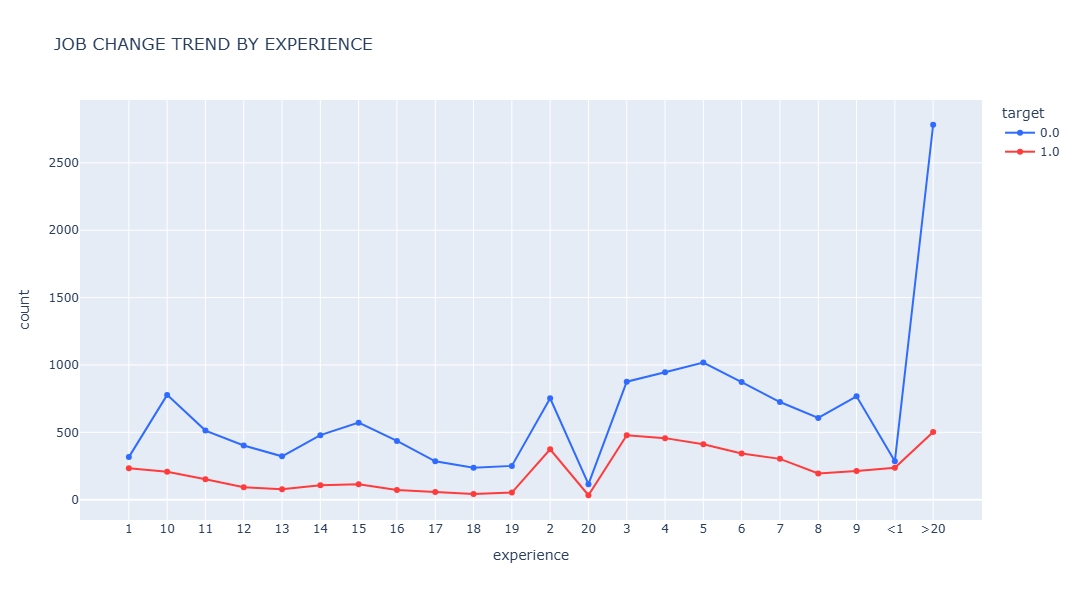

In [10]:
data = df.groupby(['experience','target']).size().reset_index(name='count')

fig = px.line(data,x='experience',y='count',color='target',markers=True, title="JOB CHANGE TREND BY EXPERIENCE",
              color_discrete_sequence=['#2F6BFF','#FF3B3B'])

fig.update_layout(width=1000, height=600)

fig.show()

## 6.BOX PLOT( CITY DEVELOPMENT INDEX BY EXPERIENCE)

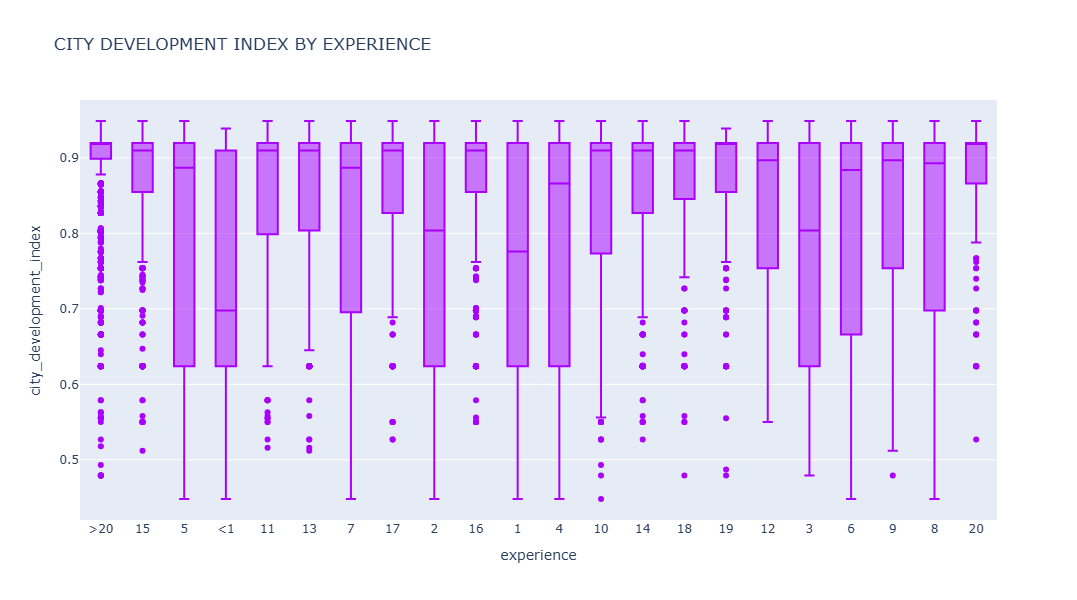

In [11]:
fig = px.box(df,
             x='experience',
             y='city_development_index',
             title="CITY DEVELOPMENT INDEX BY EXPERIENCE",color_discrete_sequence=['#AA00FF'])


fig.update_layout(width=1000, height=600)

fig.show()

## 7.SCATTER PLOT( CITY DEVELOPMENT INDEX VS TRAINING HOURS)

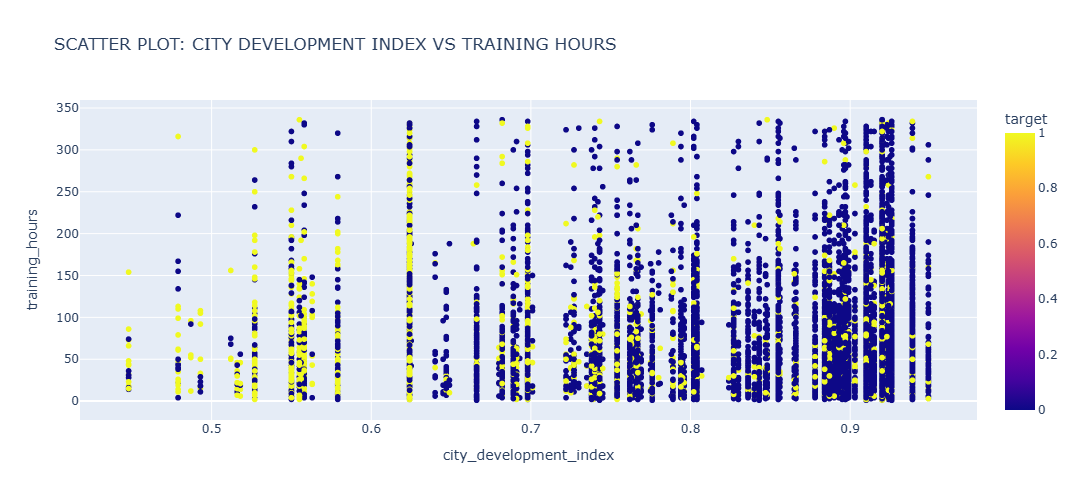

In [12]:
import pandas as pd
import plotly.express as px


df = pd.read_csv('aug_train.csv')


fig = px.scatter(df,
    x='city_development_index',
    y='training_hours',
    color='target',  # adds category (0 or 1)
    title="SCATTER PLOT: CITY DEVELOPMENT INDEX VS TRAINING HOURS",
    color_discrete_sequence=['#2962FF', '#FF3D00'])


fig.update_layout(width=900, height=500)

fig.show()

## VISUALIZATION SUMMARY 

* Bar Chart (Target Distribution): The target variable shows how candidates are distributed across     categories,   indicating whether the dataset is balanced or slightly skewed toward a particular      group.
* Histogram (Education Level): The distribution of education levels reveals that most candidates       belong to a     few dominant categories, while higher education levels are comparatively less        frequent.
* Pie Chart (Experience Distribution): The proportion of candidates across different experience        levels shows     that a majority fall within mid-level experience, with fewer candidates in          extreme  categories.
* Violin Plot (Experience vs Training Hours): This plot highlights the spread and density of           training hours      across different experience levels, showing variations and concentration         patterns within groups.
* Line Chart (Experience vs Job Change Count): The trend indicates how job changes vary with           experience,         suggesting that candidates with certain experience levels tend to switch jobs    more frequently.
* Box Plot (City Development Index by Experience): The distribution shows how candidates from          different          experience levels are spread across cities with varying development indices,      including the presence of         outliers.
* Scatter Plot (City Development Index vs Training Hours): This plot shows a weak relationship         between city      development and training hours, indicating that training is not strongly           influenced by the development level   of the city.

<div style="border:2px solid #000; padding:18px; border-radius:10px;">

<h2 style="text-align:center; font-weight:bold;">
📊 Overall Project Insights
</h2>

<h3>🔹 1. Data Loading & Initial Overview</h3>
<p>
The dataset was successfully loaded and inspected using basic functions like <b>.head()</b>, <b>.info()</b>, and <b>.describe()</b>.
Initial exploration revealed a mix of categorical and numerical features such as experience, education level, city development index, and training hours.
Some columns contained inconsistent formats (e.g., experience in text form), indicating the need for preprocessing.
</p>

<h3>🔹 2. Data Preprocessing</h3>
<p>
The experience column was cleaned by converting text values (like “2 years”, “>20”, “<1”) into numeric format.
Missing values were identified and handled using appropriate techniques such as median imputation.
Data types were corrected to ensure proper analysis and avoid errors during computations.
Overall, preprocessing improved data quality, consistency, and usability.
</p>

<h3>🔹 3. Exploratory Data Analysis (EDA)</h3>
<p>
EDA helped in understanding the distribution and relationships between variables.
Key variables like experience, training hours, and target were analyzed to identify patterns.
</p>

<ul>
<li>Experience levels vary significantly across candidates.</li>
<li>Training hours are not uniformly distributed.</li>
<li>The target variable shows some level of imbalance.</li>
<li>Correlation analysis indicated weak to moderate relationships among variables.</li>
</ul>

<h3>🔹 4. Visualization Insights</h3>
<p>
Various plots (bar chart, histogram, pie chart, box plot, violin plot, scatter plot, and line chart) were used to visually interpret the data.
</p>

<ul>
<li>Differences in candidate distribution across target categories.</li>
<li>Concentration of candidates in mid-level experience groups.</li>
<li>Variation in training hours across experience levels.</li>
<li>Weak relationship between city development index and training hours.</li>
<li>Patterns in job changes based on experience.</li>
</ul>

<h3>🔹 5. Overall Conclusion</h3>
<p>
The project demonstrates that experience, education, and training hours play an important role in influencing the target variable.
However, relationships between variables are generally not very strong, suggesting that multiple factors contribute to outcomes.
The dataset shows moderate variation and some imbalance, making it suitable for further predictive modeling.
Proper data preprocessing was crucial in ensuring accurate analysis and meaningful insights.
</p>

<h3>🔹 Final Statement</h3>
<p>
Overall, this project highlights the importance of data cleaning, exploration, and visualization in uncovering meaningful patterns. The insights derived can support better decision-making in areas such as candidate selection, training strategies, and workforce planning.
</p>

</div>